Data Mining - Kelompok 7
1.   Gabriel Martin Prasona - 2802538624
2.   Kevin Tanwiputra - 28025
3.   Lynel Angelica Madelyn - 2802539841
4.   Nicholas William - 2802539892
5.   Oktavianus Kimmy - 2802540055







UCI Bank Marketing Dataset

# Phase 1: Data Understanding and Preprocessing

Import Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.feature_selection import mutual_info_classif

Matplotlib is building the font cache; this may take a moment.


In [2]:
import warnings

warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    module="jupyter_client"
)

Import Dataset

In [3]:
csv_data = "https://drive.google.com/uc?id=1j-m814Njq4DEQfueaP3SFHBvP_zLOrKE"
data = pd.read_csv(csv_data)
raw_data = data.copy()

In [4]:
data.shape

(45211, 17)

Terdapat 45211 baris dan 17 kolom

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


Dataset memiliki 45.211 baris dan 17 kolom, dengan 7 kolom bertipe numerik dan 10 kolom bertipe kategorikal. Seluruh kolom tidak memiliki nilai kosong, dengan kolom **y** sebagai target variabel.

In [6]:
data.nunique()

age            77
job            12
marital         3
education       4
default         2
balance      7168
housing         2
loan            2
contact         3
day            31
month          12
duration     1573
campaign       48
pdays         559
previous       41
poutcome        4
y               2
dtype: int64

In [7]:
data['contact'].value_counts()

contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

Kolom **contact** memiliki 3 kategori, yaitu cellular (29.285), unknown (13.020), dan telephone (2.906).

In [8]:
data['poutcome'].value_counts()

poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

Kolom **poutcome** memiliki 4 kategori, yaitu unknown (36.959), failure (4.901), other (1.840), dan success (1.511).

In [9]:
data.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


Kode ini menampilkan 5 baris pertama dataset sebagai gambaran awal struktur dan isi data.


Mengecek Distribusi Data

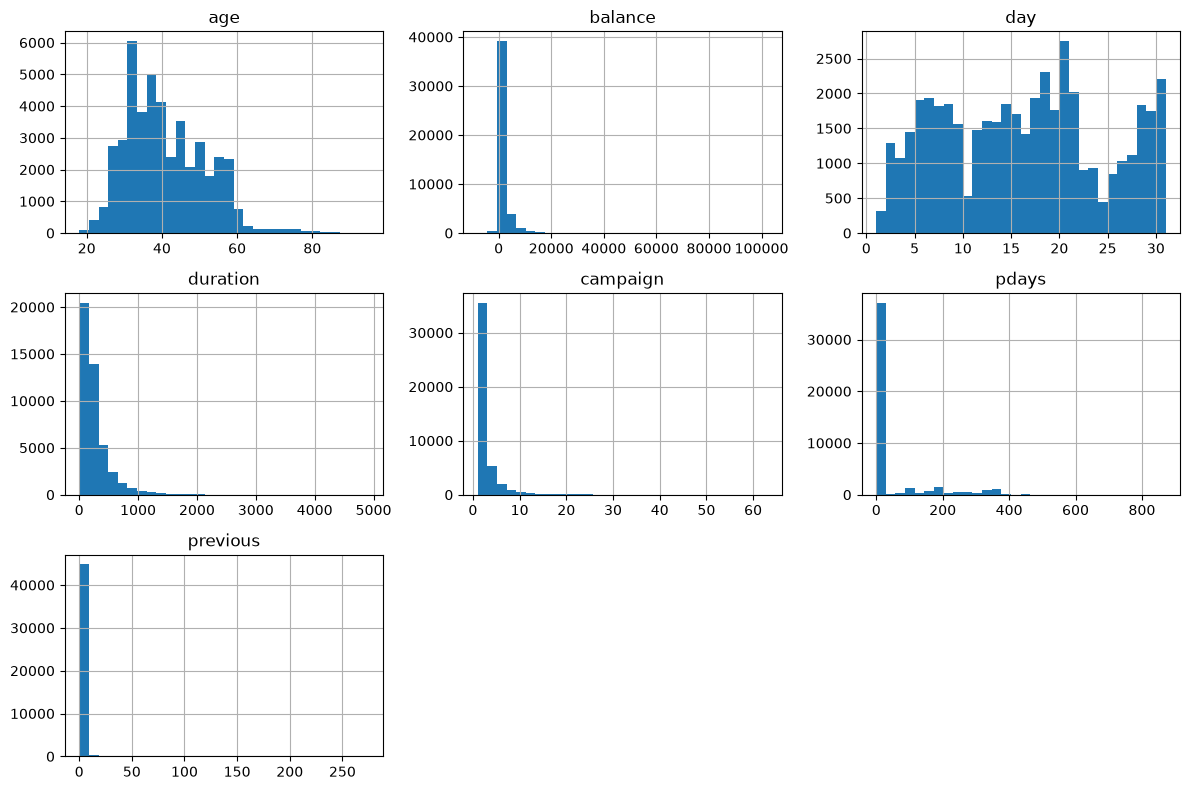

In [10]:
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns

data[numeric_cols].hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

Dari visualisasi terlihat bahwa sebagian besar kolom seperti balance, duration, campaign, pdays, dan previous memiliki distribusi yang sangat condong ke kanan (*right-skewed*), sementara kolom age memiliki distribusi yang lebih mendekati normal.

Melihat Penyebaran Data

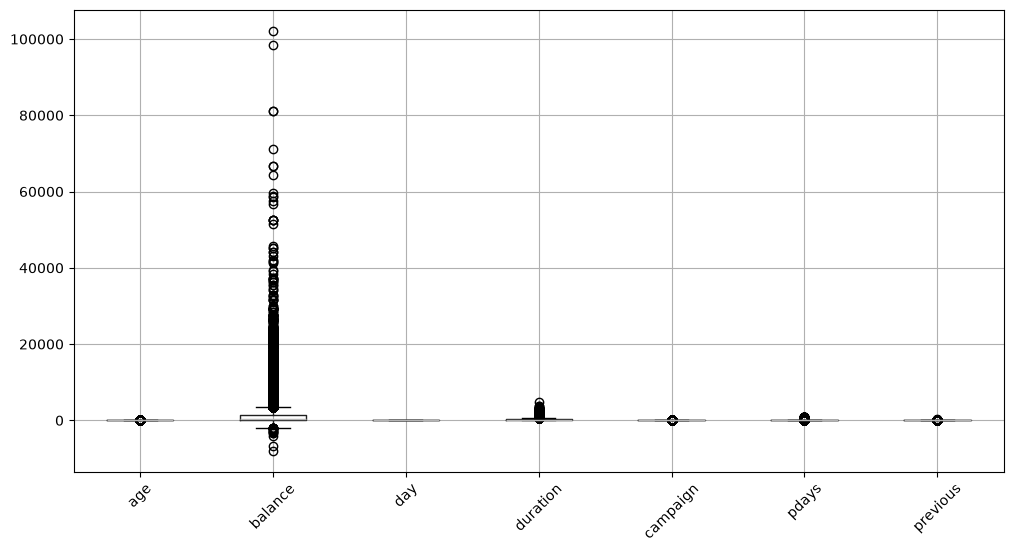

In [11]:
data[numeric_cols].boxplot(figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

Dari visualisasi boxplot terlihat bahwa kolom **balance** memiliki outlier yang sangat ekstrem hingga mencapai nilai 100.000, sementara kolom lainnya seperti duration, campaign, pdays, dan previous juga memiliki outlier namun dalam skala yang jauh lebih kecil.

In [12]:
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns

outlier_summary = {}

for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]

    outlier_summary[col] = len(outliers)

print("Jumlah outlier per kolom:")
print(outlier_summary)

Jumlah outlier per kolom:
{'age': 487, 'balance': 4729, 'day': 0, 'duration': 3235, 'campaign': 3064, 'pdays': 8257, 'previous': 8257}


Kolom **pdays** dan **previous** memiliki outlier terbanyak (8.257), diikuti **balance** (4.729), **duration** (3.235), dan **campaign** (3.064), sementara kolom **day** tidak memiliki outlier sama sekali.

Data Cleaning

Cek Missing Column

In [13]:
data.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Cek Missing Values

In [14]:
missing = data.isnull().sum().sort_values(ascending=False)
missing_percent = (data.isnull().sum()/len(data) * 100).sort_values(ascending=False)
pd.concat([missing, missing_percent], axis=1, keys=['missing_count','missing_percent'])

,missing_count,missing_percent
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
day,0,0.0


In [15]:
df = data.rename(columns={
    "y": "is_subscribed",
    "default": "credit_default"
})

Kolom y dan default diganti menjadi is_subscribed dan credit_default untuk meningkatkan interpretability, karena nama awal terlalu singkat dan ambigu sehingga tidak mencerminkan makna sebenarnya dari data. Penamaan yang lebih deskriptif membantu memahami variabel secara langsung tanpa perlu referensi tambahan.

In [16]:
df.head()

,age,job,marital,education,credit_default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,is_subscribed
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


Kode ini menampilkan 5 baris pertama dataset sebagai gambaran awal struktur dan isi data.

In [17]:
df['job'] = df['job'].replace('admin.', 'admin')

Nilai admin. pada kolom job distandardisasi menjadi admin karena hanya berbeda pada penulisan. Hal ini dilakukan agar proses encoding dan analisis tidak memisahkan kategori yang sebenarnya sama.

In [18]:
df['job'].unique()

<StringArray>
[   'management',    'technician',  'entrepreneur',   'blue-collar',
       'unknown',       'retired',         'admin',      'services',
 'self-employed',    'unemployed',     'housemaid',       'student']
Length: 12, dtype: str

In [19]:
df.duplicated().sum()

np.int64(0)

Ditemukan 0 duplikat, sehingga tidak diperlukan penghapusan baris

Data Transformation

Normalization

In [20]:
from sklearn.preprocessing import RobustScaler
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

scaler = RobustScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

Kolom numerik diskalakan menggunakan RobustScaler karena dataset ini memiliki banyak outlier, terutama pada kolom pdays, previous, dan balance. RobustScaler menggunakan median dan IQR sehingga tidak terpengaruh oleh nilai ekstrem, berbeda dengan StandardScaler yang menggunakan mean dan standar deviasi sehingga lebih sensitif terhadap outlier.

In [21]:
df[numeric_cols].describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.00000,45211.000000,45211.000000
mean,0.129081,0.674242,-0.014891,0.361866,0.38192,41.197828,0.580323
std,0.707917,2.245403,0.640190,1.192258,1.54901,100.128746,2.303441
min,-1.400000,-6.244100,-1.153846,-0.833333,-0.50000,0.000000,0.000000
25%,-0.400000,-0.277286,-0.615385,-0.356481,-0.50000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
75%,0.600000,0.722714,0.384615,0.643519,0.50000,0.000000,0.000000
max,3.733333,74.984513,1.153846,21.935185,30.50000,872.000000,275.000000


Setelah dilakukan scaling, nilai pada seluruh kolom numerik telah terskala dengan median di angka 0, namun terlihat bahwa beberapa kolom seperti balance dan previous masih memiliki nilai maksimum yang sangat jauh dari median, yang mengindikasikan outlier ekstrem masih tetap ada meskipun sudah menggunakan RobustScaler.

In [22]:
df.head(5)

,age,job,marital,education,credit_default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,is_subscribed
0,1.266667,management,married,tertiary,no,1.250000,yes,no,unknown,-0.846154,may,0.375000,-0.5,0.0,0.0,unknown,no
1,0.333333,technician,single,secondary,no,-0.308997,yes,no,unknown,-0.846154,may,-0.134259,-0.5,0.0,0.0,unknown,no
2,-0.400000,entrepreneur,married,secondary,no,-0.328909,yes,yes,unknown,-0.846154,may,-0.481481,-0.5,0.0,0.0,unknown,no
3,0.533333,blue-collar,married,unknown,no,0.780236,yes,no,unknown,-0.846154,may,-0.407407,-0.5,0.0,0.0,unknown,no
4,-0.400000,unknown,single,unknown,no,-0.329646,no,no,unknown,-0.846154,may,0.083333,-0.5,0.0,0.0,unknown,no


Binning

Binning dilakukan menggunakan qcut. qcut dipilih karena data memiliki distribusi tidak merata (skewed) dan mengandung outlier, sehingga pembagian berdasarkan quantile agar menghasilkan jumlah data yang seimbang di setiap bin.

In [23]:
df['age_bin'] = pd.qcut(
    df['age'],
    q=4,
    labels=['young', 'adult', 'middle_age', 'senior']
)

Kolom age dipilih untuk binning karena usia memiliki makna yang lebih informatif ketika dikelompokkan berdasarkan kategori kehidupan. Metode qcut digunakan agar setiap kelompok memiliki jumlah data yang seimbang, dengan 4 kelompok yaitu young, adult, middle_age, dan senior.

In [24]:
df['balance_bin'] = pd.qcut(
    df['balance'],
    q=4,
    labels=['low', 'medium', 'high', 'very_high']
)

Kolom **balance** dikelompokkan menjadi 4 kategori yaitu low, medium, high, dan very_high menggunakan **qcut** agar setiap kelompok memiliki jumlah data yang seimbang.

In [25]:
df['duration_bin'] = pd.qcut(
    df['duration'],
    q=4,
    labels=['short', 'medium', 'long', 'very_long']
)

Kolom duration dikelompokkan menjadi 4 kategori yaitu short, medium, long, dan very_long menggunakan qcut agar setiap kelompok memiliki jumlah data yang seimbang.

In [26]:
df = df.drop(['age', 'balance', 'duration'], axis=1)

Encoding

In [27]:
df['education'].unique()

<StringArray>
['tertiary', 'secondary', 'unknown', 'primary']
Length: 4, dtype: str

In [28]:
month_mapping = {
    'jan':1, 'feb':2, 'mar':3, 'apr':4, 'may':5, 'jun':6,
    'jul':7, 'aug':8, 'sep':9, 'oct':10, 'nov':11, 'dec':12
}

df['month'] = df['month'].map(month_mapping)

Month dilakukan encoding dengan metode mapping karena merupakan variabel ordinal yang memiliki urutan waktu, sehingga direpresentasikan dalam bentuk numerik (1–12) agar hubungan kronologis antar bulan tetap terjaga.


In [29]:
edu_mapping = {
    'unknown': 0,
    'primary':1,
    'secondary':2,
    'tertiary':3
}

df['education'] = df['education'].map(edu_mapping)

Education di-encode dengan mapping karena bersifat ordinal, sehingga urutannya tetap terjaga.


In [30]:
binary_cols = ['credit_default', 'housing', 'loan', 'is_subscribed']

for col in binary_cols:
    df[col] = df[col].map({'yes':1, 'no':0})

Kolom biner di-encode menjadi 0 dan 1 karena hanya memiliki dua kategori, sehingga memudahkan pemrosesan oleh model.


In [31]:
df = pd.get_dummies(
    df,
    columns=['age_bin', 'balance_bin', 'duration_bin'],
    drop_first=True,
    dtype=int
)

Kolom hasil binning di encode dengan One-Hot Encoding karena bersifat kategorikal, sehingga diubah menjadi variabel biner agar dapat digunakan dalam analisis.


In [32]:
df = pd.get_dummies(
    df,
    columns=['job', 'marital', 'contact', 'poutcome'],
    drop_first=True
)

bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

Kolom kategorikal di encode dengan One-Hot Encoding karena tidak memiliki urutan, lalu dikonversi ke 0/1 agar dapat diproses oleh model.


In [33]:
df.head(5)

,education,credit_default,housing,loan,day,month,campaign,pdays,previous,is_subscribed,...,job_technician,job_unemployed,job_unknown,marital_married,marital_single,contact_telephone,contact_unknown,poutcome_other,poutcome_success,poutcome_unknown
0,3,0,1,0,-0.846154,5,-0.5,0.0,0.0,0,...,0,0,0,1,0,0,1,0,0,1
1,2,0,1,0,-0.846154,5,-0.5,0.0,0.0,0,...,1,0,0,0,1,0,1,0,0,1
2,2,0,1,1,-0.846154,5,-0.5,0.0,0.0,0,...,0,0,0,1,0,0,1,0,0,1
3,0,0,1,0,-0.846154,5,-0.5,0.0,0.0,0,...,0,0,0,1,0,0,1,0,0,1
4,0,0,0,0,-0.846154,5,-0.5,0.0,0.0,0,...,0,0,1,0,1,0,1,0,0,1


Correlation Analysis

In [34]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[num_cols].corr()

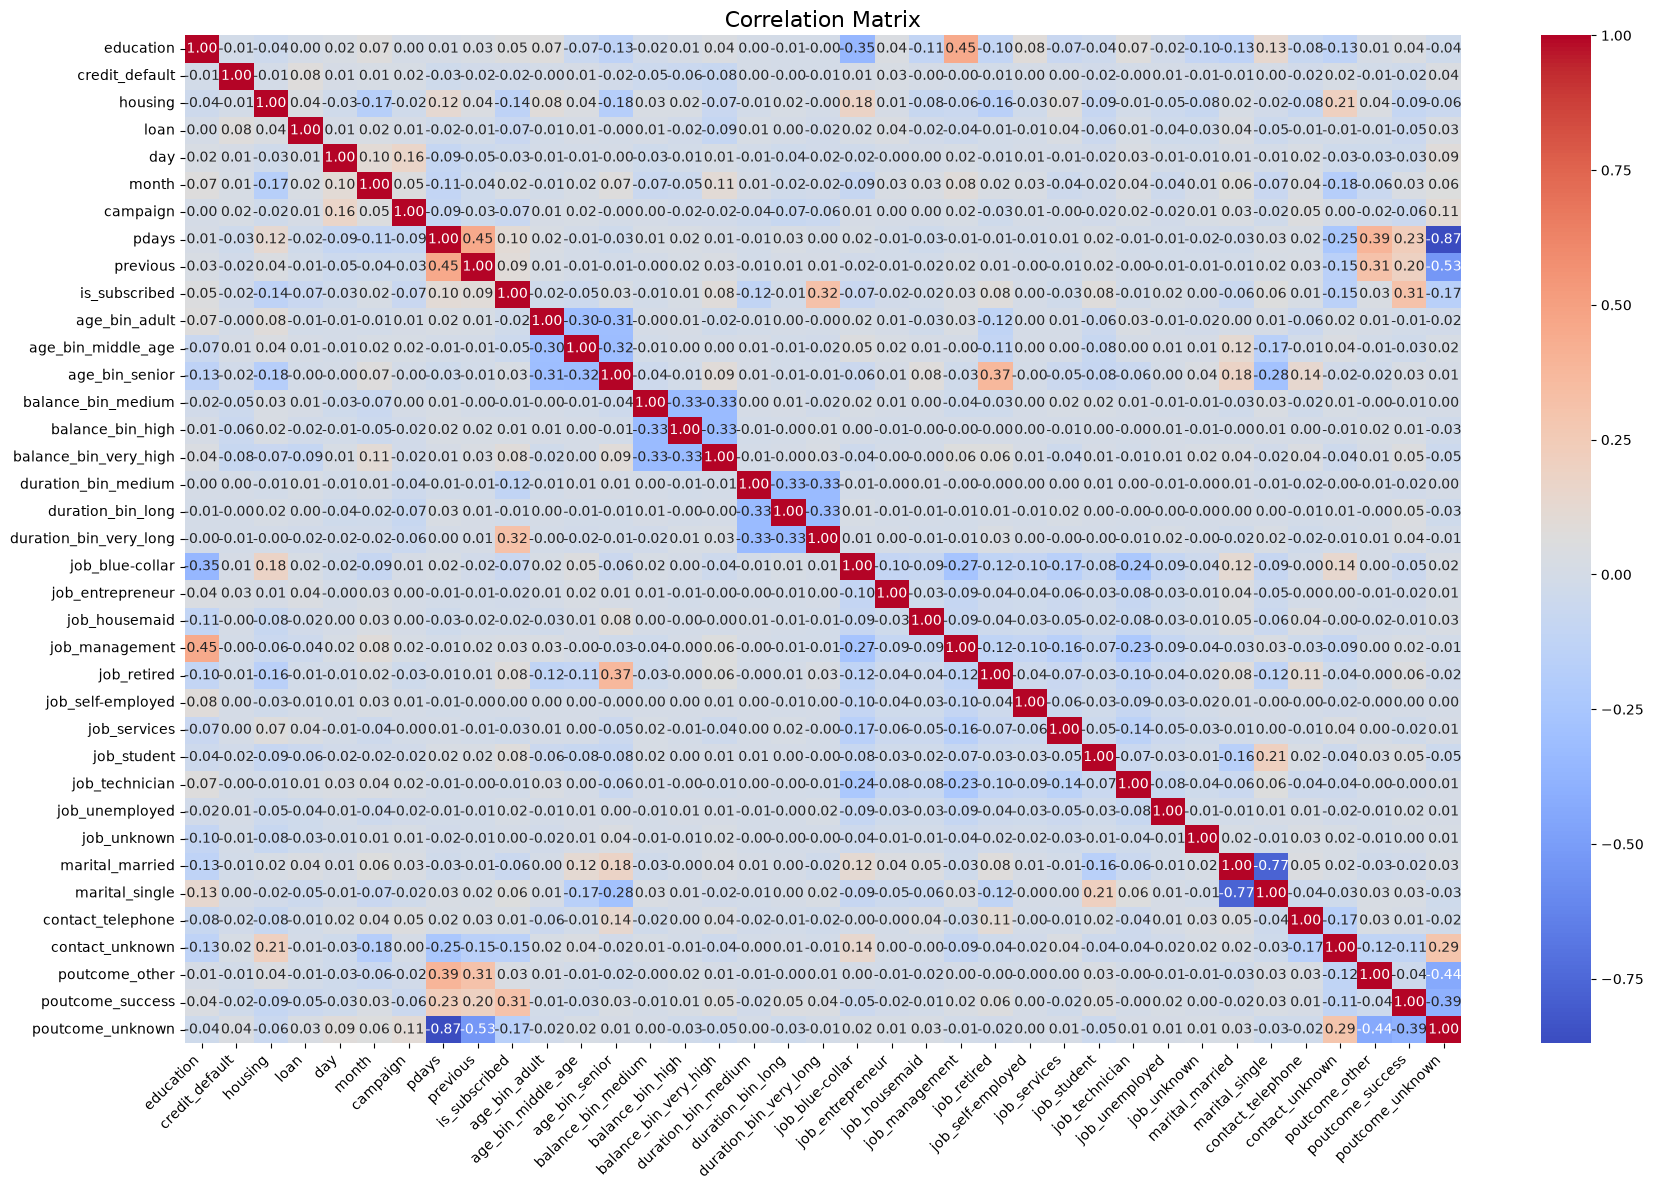

In [35]:
plt.figure(figsize=(18,12))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    annot_kws={"size": 10}
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()

Dari visualisasi heatmap korelasi terlihat bahwa sebagian besar fitur memiliki korelasi yang rendah terhadap satu sama lain, sehingga tidak terdapat masalah multikolinearitas yang signifikan. Tidak ada pasangan fitur yang memiliki korelasi sangat tinggi (mendekati 1 atau -1), yang berarti seluruh fitur masih layak untuk dipertahankan sebelum dilakukan seleksi lebih lanjut.

In [36]:
X = df.drop('is_subscribed', axis=1)
y = df['is_subscribed']

Memisahkan dataset menjadi fitur (X) dan target (y), dimana X berisi semua variabel prediktor dan y adalah label yang ingin diprediksi (is_subscribed).

In [37]:
corr_matrix = X.corr()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(abs(upper[col]) > 0.8)]

print("Fitur dihapus (correlation):", to_drop)

X_corr = X.drop(columns=to_drop)

Fitur dihapus (correlation): ['poutcome_unknown']


poutcome_unknown dihapus karena informasinya sudah terwakili oleh kategori lain (poutcome_success dan poutcome_other), sehingga untuk menghindari redundansi dan multikolinearitas cukup menyisakan kategori lainnya.

In [38]:
mi_scores = mutual_info_classif(X_corr, y, random_state=42)

mi_df = pd.DataFrame({
    'Feature': X_corr.columns,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False)

print(mi_df)

                   Feature  MI Score
17  duration_bin_very_long  0.045773
34        poutcome_success  0.029919
7                    pdays  0.026795
5                    month  0.024371
32         contact_unknown  0.016454
2                  housing  0.015901
8                 previous  0.009906
15     duration_bin_medium  0.008704
29         marital_married  0.007824
0                education  0.007347
4                      day  0.005171
30          marital_single  0.004165
6                 campaign  0.003430
14   balance_bin_very_high  0.003418
21          job_management  0.002734
18         job_blue-collar  0.002639
3                     loan  0.002569
16       duration_bin_long  0.001884
1           credit_default  0.001821
9            age_bin_adult  0.001695
22             job_retired  0.001423
31       contact_telephone  0.001387
27          job_unemployed  0.001081
19        job_entrepreneur  0.001036
24            job_services  0.000825
28             job_unknown  0.000806
1

Rendahnya nilai MI pada sebagian besar fitur, khususnya hasil one-hot encoding, menunjukkan bahwa informasi tersebar dalam banyak variabel sehingga kontribusi individual menjadi kecil.

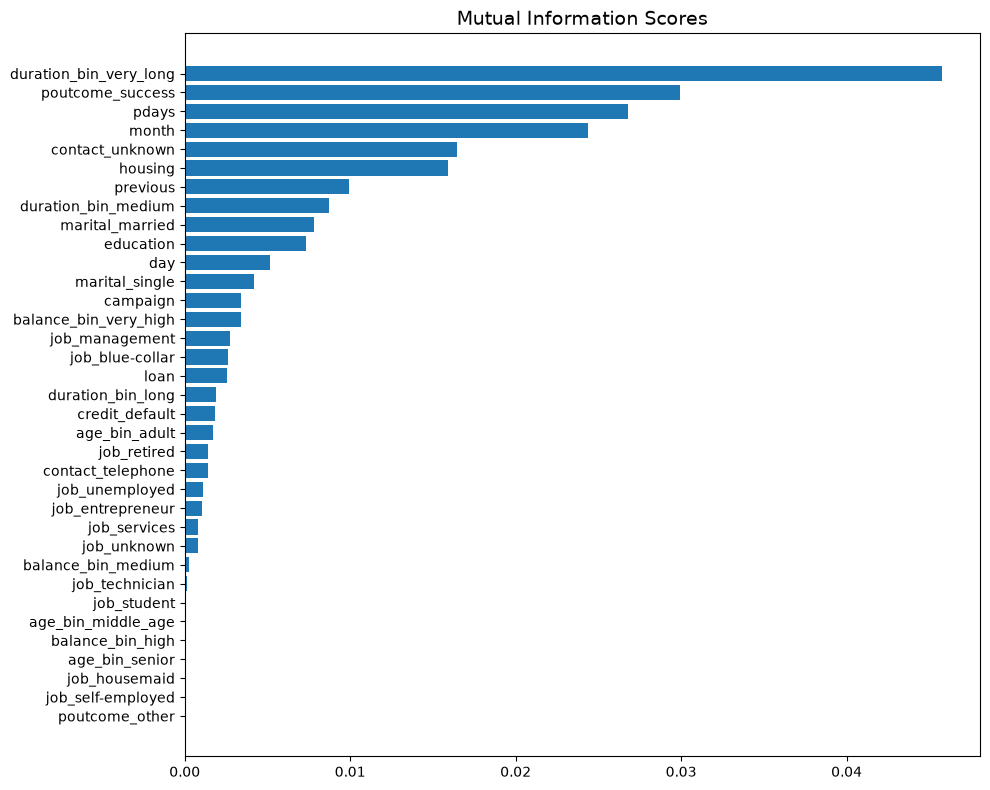

In [39]:
plt.figure(figsize=(10,8))
plt.barh(mi_df['Feature'], mi_df['MI Score'])
plt.gca().invert_yaxis()
plt.title("Mutual Information Scores", fontsize=14)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

Feature selection utama menggunakan Mutual Information karena mampu menangkap hubungan non-linear antara fitur dan target, sedangkan correlation hanya mengukur hubungan linear sehingga kurang representatif.

In [40]:
top_n = 15
selected_features = mi_df.head(top_n)['Feature'].tolist()
selected_features = [f for f in selected_features if f in X.columns]
X_selected = X[selected_features]
print(selected_features)

['duration_bin_very_long', 'poutcome_success', 'pdays', 'month', 'contact_unknown', 'housing', 'previous', 'duration_bin_medium', 'marital_married', 'education', 'day', 'marital_single', 'campaign', 'balance_bin_very_high', 'job_management']


Hasil feature selection menunjukkan bahwa fitur seperti duration_bin_very_long, poutcome_success, pdays, month, contact_unknown, housing, dan previous menjadi faktor yang paling informatif dalam merepresentasikan perilaku interaksi nasabah dengan bank. Sementara itu, fitur marital_married, marital_single, education, balance_bin_very_high, dan job_management menunjukkan bahwa karakteristik demografis dan finansial juga berperan dalam memengaruhi keputusan pelanggan.

In [41]:
initial_features = X.shape[1]
selected_feature_count = X_selected.shape[1]

print("Jumlah fitur awal:", initial_features)
print("Jumlah fitur terpilih:", selected_feature_count)

Jumlah fitur awal: 36
Jumlah fitur terpilih: 15


Sebanyak 15 fitur dipilih dari total 36 fitur berdasarkan nilai Mutual Information tertinggi. Pemilihan ini bertujuan untuk mempertahankan fitur yang paling informatif terhadap target sekaligus mengurangi noise dan kompleksitas model.

In [42]:
df_clean = X.copy()
df_clean["is_subscribed"] = y
df_clean.to_csv("bank_marketing_clean.csv", index=False)
print(f"Clean dataset berhasil diexport: {df_clean.shape[0]} baris, {df_clean.shape[1]} kolom")

Clean dataset berhasil diexport: 45211 baris, 37 kolom


In [ ]:
# X_selected.to_csv("X_selected.csv", index=False)
# raw_data.to_csv("raw_data.csv", index=False)
# data.to_csv("data.csv", index=False)
# X_corr.to_csv("X_corr.csv", index=False)
# pd.DataFrame(selected_features, columns=['Feature']).to_csv('selected_features.csv', index=False)